# Churn Prediction: Model Training, Evaluation, and Optimization

Trains and compares two churn classifiers on the user-level feature table — a class-balanced logistic regression baseline and a regularized random forest — then moves from raw metrics to deployment decisions: confusion-matrix reading, decision-threshold tuning, hyperparameter comparison, driver interpretation (coefficients and feature importances), and probability-based risk segmentation.

## 1. Data Loading

Churn modeling works from the user-level feature snapshot, so only `feature_table` is loaded.

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

from src.data_loader import load_table

df_raw = load_table('feature_table')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (50000, 53)


,user_id,snapshot_date,signup_date,tenure_days,country,language,region_tier,age_group,primary_device,acquisition_channel,student_eligible,marketing_opt_in,music_persona,subscription_type,lifecycle_stage,active_days_7d,listen_events_7d,listen_minutes_7d,active_days_30d,listen_events_30d,listen_minutes_30d,sessions_30d,avg_play_duration_sec_30d,skip_rate_30d,completion_rate_30d,liked_songs_30d,playlist_adds_30d,search_events_30d,top_genre_30d,ad_impressions_30d,ad_clicks_30d,ad_click_rate_30d,ad_completions_30d,ad_completion_rate_30d,ad_impressions_per_active_day,ad_load_bucket,ad_revenue_30d,trial_exposed_30d,trial_started_30d,trial_used_before_snapshot,paid_started_30d,paid_conversion_30d,renewal_success_30d,payment_failed_30d,cancel_30d,trial_expired_30d,renewal_success_14d,subscription_revenue_30d,total_revenue_30d,active_level_30d,listening_level_30d,listen_events_14d,churn_label_14d
0,U000001,2026-04-01,2026-02-06,54,UK,en,Tier 1,35-44,mobile_android,organic_search,0,0,commute_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,1.9333,1.0,116.0,0.00,0.0,0.0,0.0,0.0,jazz,3.0,0.0,0.0,2.0,0.6667,3.0000,medium,0.0438,0,0,0,0,0,0,0,1,0,0,0.0,0.0438,low,very_low,2,0
1,U000002,2026-04-01,2026-03-07,25,ES,es,Tier 2,25-34,mobile_android,paid_social,0,0,playlist_builder,free,engaged_free,3.0,3.0,7.1167,10.0,10.0,21.5500,10.0,129.3,0.20,0.3,1.0,1.0,2.0,rock,7.0,0.0,0.0,6.0,0.8571,0.7000,low,0.0544,1,0,0,0,0,0,0,0,0,0,0.0,0.0544,medium,low,0,1
2,U000003,2026-04-01,2025-07-29,246,IN,en,Tier 2,18-24,mobile_android,referral,0,0,casual_listener,free,casual_free,1.0,1.0,2.6500,3.0,3.0,6.5000,3.0,130.0,0.00,0.0,0.0,0.0,0.0,pop,1.0,0.0,0.0,0.0,0.0000,0.3333,low,0.0025,0,0,0,0,0,0,0,0,0,0,0.0,0.0025,low,very_low,0,1
3,U000004,2026-04-01,2025-11-14,138,FR,fr,Tier 1,35-44,mobile_android,referral,0,1,commute_listener,free,casual_free,1.0,1.0,0.6000,4.0,4.0,11.3333,4.0,170.0,0.25,0.0,0.0,0.0,3.0,classical,2.0,0.0,0.0,1.0,0.5000,0.5000,low,0.0703,0,0,1,0,0,0,0,0,0,0,0.0,0.0703,medium,low,3,0
4,U000005,2026-04-01,2025-05-21,315,US,en,Tier 1,25-34,mobile_ios,student_partner,1,0,casual_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,2.7167,1.0,163.0,0.00,0.0,0.0,0.0,0.0,jazz,0.0,0.0,0.0,0.0,0.0000,0.0000,no_ads,0.0000,0,0,0,0,0,0,0,0,0,0,0.0,0.0000,low,very_low,2,0


## 2. Modeling Table Preparation

Standardizes column aliases across data versions, fills conservative defaults for optional columns, and enforces a clean binary target.

In [2]:
# The data-preparation logic is frozen in src/churn_modeling.py — the
# single source of the modeling protocol, reused by notebooks 07+.
from src.churn_modeling import prepare_modeling_table

df = prepare_modeling_table(df_raw)
print('Prepared modeling table:', df.shape)
print('Churn rate:', df['churn_label_14d'].mean().round(4))
df.head()

Prepared modeling table: (50000, 58)
Churn rate: 0.4756


,user_id,snapshot_date,signup_date,tenure_days,country,language,region_tier,age_group,primary_device,acquisition_channel,student_eligible,marketing_opt_in,music_persona,subscription_type,lifecycle_stage,active_days_7d,listen_events_7d,listen_minutes_7d,active_days_30d,listen_events_30d,listen_minutes_30d,sessions_30d,avg_play_duration_sec_30d,skip_rate_30d,completion_rate_30d,liked_songs_30d,playlist_adds_30d,search_events_30d,top_genre_30d,ad_impressions_30d,ad_clicks_30d,ad_click_rate_30d,ad_completions_30d,ad_completion_rate_30d,ad_impressions_per_active_day,ad_load_bucket,ad_revenue_30d,trial_exposed_30d,trial_started_30d,trial_used_before_snapshot,paid_started_30d,paid_conversion_30d,renewal_success_30d,payment_failed_30d,cancel_30d,trial_expired_30d,renewal_success_14d,subscription_revenue_30d,total_revenue_30d,active_level_30d,listening_level_30d,listen_events_14d,churn_label_14d,device,playlist_count_30d,liked_song_count_30d,ad_load_per_active_day,top_genre
0,U000001,2026-04-01,2026-02-06,54,UK,en,Tier 1,35-44,mobile_android,organic_search,0,0,commute_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,1.9333,1.0,116.0,0.00,0.0,0.0,0.0,0.0,jazz,3.0,0.0,0.0,2.0,0.6667,3.0000,medium,0.0438,0,0,0,0,0,0,0,1,0,0,0.0,0.0438,low,very_low,2,0,mobile_android,0.0,0.0,3.0000,jazz
1,U000002,2026-04-01,2026-03-07,25,ES,es,Tier 2,25-34,mobile_android,paid_social,0,0,playlist_builder,free,engaged_free,3.0,3.0,7.1167,10.0,10.0,21.5500,10.0,129.3,0.20,0.3,1.0,1.0,2.0,rock,7.0,0.0,0.0,6.0,0.8571,0.7000,low,0.0544,1,0,0,0,0,0,0,0,0,0,0.0,0.0544,medium,low,0,1,mobile_android,1.0,1.0,0.7000,rock
2,U000003,2026-04-01,2025-07-29,246,IN,en,Tier 2,18-24,mobile_android,referral,0,0,casual_listener,free,casual_free,1.0,1.0,2.6500,3.0,3.0,6.5000,3.0,130.0,0.00,0.0,0.0,0.0,0.0,pop,1.0,0.0,0.0,0.0,0.0000,0.3333,low,0.0025,0,0,0,0,0,0,0,0,0,0,0.0,0.0025,low,very_low,0,1,mobile_android,0.0,0.0,0.3333,pop
3,U000004,2026-04-01,2025-11-14,138,FR,fr,Tier 1,35-44,mobile_android,referral,0,1,commute_listener,free,casual_free,1.0,1.0,0.6000,4.0,4.0,11.3333,4.0,170.0,0.25,0.0,0.0,0.0,3.0,classical,2.0,0.0,0.0,1.0,0.5000,0.5000,low,0.0703,0,0,1,0,0,0,0,0,0,0,0.0,0.0703,medium,low,3,0,mobile_android,0.0,0.0,0.5000,classical
4,U000005,2026-04-01,2025-05-21,315,US,en,Tier 1,25-34,mobile_ios,student_partner,1,0,casual_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,2.7167,1.0,163.0,0.00,0.0,0.0,0.0,0.0,jazz,0.0,0.0,0.0,0.0,0.0000,0.0000,no_ads,0.0000,0,0,0,0,0,0,0,0,0,0,0.0,0.0000,low,very_low,2,0,mobile_ios,0.0,0.0,0.0000,jazz


## 3. Features and Target

Nine behavioral and tenure numerics plus five categorical descriptors; the target is the 14-day churn label. Feature lists are filtered to columns actually present so minor schema differences don't break the run.

In [3]:
numeric_features = [
    'active_days_30d',
    'listen_minutes_30d',
    'sessions_30d',
    'playlist_count_30d',
    'liked_song_count_30d',
    'search_events_30d',
    'skip_rate_30d',
    'ad_load_per_active_day',
    'tenure_days'
]

categorical_features = [
    'subscription_type',
    'device',
    'acquisition_channel',
    'country',
    'top_genre'
]

target_col = 'churn_label_14d'

# Keep only columns that actually exist to tolerate minor schema differences.
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target distribution:')
print(y.value_counts(normalize=True).rename('share'))

Numeric features: ['active_days_30d', 'listen_minutes_30d', 'sessions_30d', 'playlist_count_30d', 'liked_song_count_30d', 'search_events_30d', 'skip_rate_30d', 'ad_load_per_active_day', 'tenure_days']
Categorical features: ['subscription_type', 'device', 'acquisition_channel', 'country', 'top_genre']
Target distribution:
churn_label_14d
0    0.52442
1    0.47558
Name: share, dtype: float64


## 4. Train-Test Split

Stratified 80/20 split preserves the churn rate in both sets; the fixed random state keeps every later comparison on identical data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train churn rate:', y_train.mean().round(4))
print('Test churn rate:', y_test.mean().round(4))

Train shape: (40000, 14)
Test shape: (10000, 14)
Train churn rate: 0.4756
Test churn rate: 0.4756


## 5. Preprocessing Pipeline

Numerics are standardized and categoricals one-hot encoded (unknown-safe). The ColumnTransformer lives inside each model's Pipeline, so preprocessing is fit on training data only — no leakage across the split.

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 6. Baseline: Logistic Regression

Class-balanced logistic regression is the interpretable baseline: stable, fast, and its coefficients communicate churn drivers directly. It also produces the churn probabilities used for threshold work later.

In [6]:
log_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED
        ))
    ]
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]

print('Logistic Regression training completed.')
print('First 5 churn probabilities:', np.round(log_proba[:5], 4))

Logistic Regression training completed.
First 5 churn probabilities: [0.7239 0.7836 0.8007 0.278  0.782 ]


## 7. Random Forest

A regularized forest (300 trees, depth 6, minimum leaf 20, class-balanced) to capture non-linear feature combinations — e.g. low activity + high ad load + no playlists on a free plan — that a linear model cannot express.

In [7]:
rf_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest training completed.')
print('First 5 churn probabilities:', np.round(rf_proba[:5], 4))

Random Forest training completed.
First 5 churn probabilities: [0.6787 0.7398 0.7924 0.2831 0.6908]


## 8. Model Comparison

Accuracy, precision, recall, F1, ROC-AUC, and PR-AUC side by side on the held-out test set. No single number decides; the metrics answer different business questions (see Modeling Decisions below).

In [8]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Return common classification metrics for one model."""
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba)
    }

model_results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, log_pred, log_proba),
    evaluate_model('Random Forest', y_test, rf_pred, rf_proba)
])

model_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.7134,0.670393,0.781749,0.721802,0.787615,0.733300
1,Random Forest,0.7069,0.662511,0.782170,0.717385,0.784306,0.730015


## 9. Confusion Matrices

The error structure behind the metrics: false positives waste intervention budget on users who would have stayed; false negatives are missed saves.

In [9]:
def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual Not Churn', 'Actual Churn'],
        columns=['Predicted Not Churn', 'Predicted Churn']
    )
    return cm_df

print('Logistic Regression Confusion Matrix')
display(show_confusion_matrix(y_test, log_pred))

print('Random Forest Confusion Matrix')
display(show_confusion_matrix(y_test, rf_pred))

Logistic Regression Confusion Matrix


,Predicted Not Churn,Predicted Churn
Actual Not Churn,3416,1828
Actual Churn,1038,3718


Random Forest Confusion Matrix


,Predicted Not Churn,Predicted Churn
Actual Not Churn,3349,1895
Actual Churn,1036,3720


## 10. Threshold Tuning

The default 0.5 cutoff is a modeling convention, not a business decision. Sweeping thresholds exposes the precision/recall frontier and the share of the user base each cutoff would flag for intervention.

In [10]:
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'predicted_churn_share': y_pred.mean()
    }

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = pd.DataFrame([
    evaluate_threshold(y_test, rf_proba, t)
    for t in thresholds
])

threshold_results

,threshold,precision,recall,f1,predicted_churn_share
0,0.2,0.553437,0.976661,0.706518,0.8393
1,0.3,0.589771,0.935870,0.723563,0.7547
2,0.4,0.619722,0.882675,0.728187,0.6774
3,0.5,0.662511,0.782170,0.717385,0.5615
4,0.6,0.713497,0.624685,0.666143,0.4164
5,0.7,0.785065,0.344828,0.479182,0.2089


## 11. Random Forest Hyperparameter Comparison

Three depth/leaf configurations on identical splits — checking whether extra capacity buys real lift or just fits noise.

In [11]:
rf_configs = [
    {'max_depth': 4, 'min_samples_leaf': 30},
    {'max_depth': 6, 'min_samples_leaf': 20},
    {'max_depth': 8, 'min_samples_leaf': 10}
]

optimization_results = []

for config in rf_configs:
    model = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', RandomForestClassifier(
                n_estimators=300,
                max_depth=config['max_depth'],
                min_samples_leaf=config['min_samples_leaf'],
                class_weight='balanced',
                random_state=RANDOM_SEED,
                n_jobs=-1
            ))
        ]
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    optimization_results.append(
        evaluate_model(
            f"RF_depth_{config['max_depth']}_leaf_{config['min_samples_leaf']}",
            y_test,
            pred,
            proba
        )
    )

optimization_results = pd.DataFrame(optimization_results)
optimization_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,RF_depth_4_leaf_30,0.7032,0.653926,0.798570,0.719046,0.781585,0.728996
1,RF_depth_6_leaf_20,0.7069,0.662511,0.782170,0.717385,0.784306,0.730015
2,RF_depth_8_leaf_10,0.7102,0.666906,0.780488,0.719240,0.785206,0.730290


## 12. Feature Names After Preprocessing

Recovers post-encoding feature names from the fitted pipeline. Written to be portable across scikit-learn versions (`get_feature_names_out` exists from 1.0; older versions assemble the names manually).

In [12]:
def get_feature_names_from_pipeline(pipeline_model):
    """Get transformed feature names from a fitted Pipeline across sklearn versions."""
    preprocessor = pipeline_model.named_steps['preprocess']
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        # scikit-learn < 1.0: assemble names manually from the transformers.
        names = []
        for name, transformer, cols in preprocessor.transformers_:
            if name == 'num':
                names.extend(f'num__{c}' for c in cols)
            elif name == 'cat':
                onehot = transformer.named_steps['onehot']
                for col, levels in zip(cols, onehot.categories_):
                    names.extend(f'cat__{col}_{level}' for level in levels)
        return np.array(names)

feature_names = get_feature_names_from_pipeline(log_model)
feature_names[:10]

array(['num__active_days_30d', 'num__listen_minutes_30d',
       'num__sessions_30d', 'num__playlist_count_30d',
       'num__liked_song_count_30d', 'num__search_events_30d',
       'num__skip_rate_30d', 'num__ad_load_per_active_day',
       'num__tenure_days', 'cat__subscription_type_family_premium'],
      dtype=object)

## 13. Logistic Regression Coefficients

Coefficient sign gives the direction of association; the odds ratio gives the multiplicative effect on churn odds per standardized unit (numerics) or category presence (one-hot columns).

In [13]:
log_classifier = log_model.named_steps['model']
feature_names = get_feature_names_from_pipeline(log_model)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_classifier.coef_[0]
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

coef_df.sort_values('abs_coefficient', ascending=False).head(20)

,feature,coefficient,abs_coefficient,odds_ratio
2,num__sessions_30d,-0.733363,0.733363,0.480291
0,num__active_days_30d,-0.497292,0.497292,0.608176
10,cat__subscription_type_free,0.398782,0.398782,1.490008
24,cat__acquisition_channel_referral,-0.375645,0.375645,0.686846
23,cat__acquisition_channel_paid_social,0.332276,0.332276,1.394138
9,cat__subscription_type_family_premium,-0.264160,0.264160,0.767851
11,cat__subscription_type_individual_premium,-0.262373,0.262373,0.769224
12,cat__subscription_type_student_premium,-0.227220,0.227220,0.796745
50,cat__top_genre_true_crime_podcast,-0.221564,0.221564,0.801265
47,cat__top_genre_no_listening,0.155185,0.155185,1.167874


## 14. Random Forest Feature Importance

Impurity-based importances for the forest's top signals. These are biased toward high-cardinality features, so they are read alongside the logistic coefficients rather than in isolation.

In [14]:
rf_classifier = rf_model.named_steps['model']
feature_names = get_feature_names_from_pipeline(rf_model)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values('importance', ascending=False)
importance_df.head(20)

,feature,importance
2,num__sessions_30d,0.235369
0,num__active_days_30d,0.225723
1,num__listen_minutes_30d,0.144268
5,num__search_events_30d,0.093452
4,num__liked_song_count_30d,0.065853
3,num__playlist_count_30d,0.050035
10,cat__subscription_type_free,0.049958
6,num__skip_rate_30d,0.045141
11,cat__subscription_type_individual_premium,0.025389
47,cat__top_genre_no_listening,0.017580


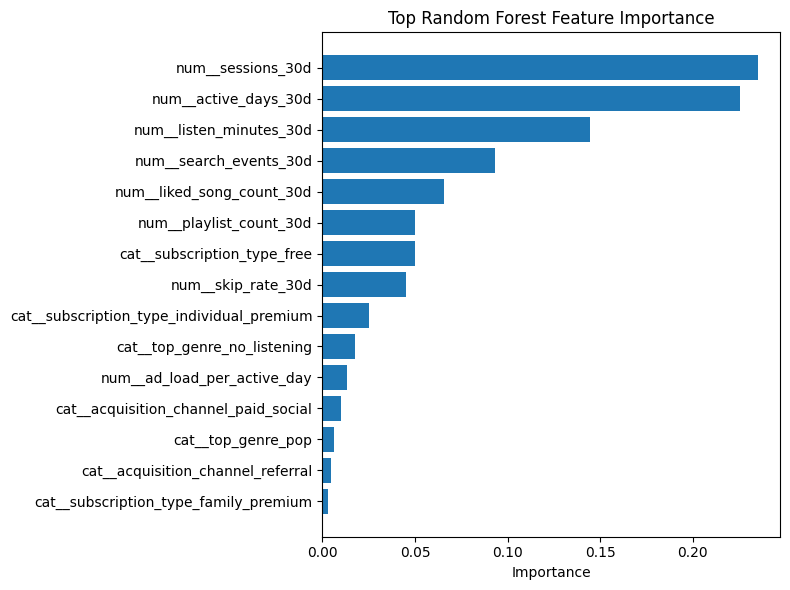

In [15]:
top_features = importance_df.head(15).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 15. Risk Segmentation

Converts model probabilities into low / medium / high risk tiers and validates calibration: each tier's actual churn rate should rise monotonically with its predicted risk, or the tiers are not actionable.

In [16]:
scoring_df = X_test.copy()
scoring_df['actual_churn'] = y_test.values
scoring_df['rf_churn_probability'] = rf_proba

scoring_df['risk_segment'] = pd.cut(
    scoring_df['rf_churn_probability'],
    bins=[-0.01, 0.4, 0.7, 1.0],
    labels=['low risk', 'medium risk', 'high risk']
)

risk_summary = (
    scoring_df.groupby('risk_segment', observed=True)
              .agg(
                  users=('rf_churn_probability', 'count'),
                  avg_predicted_risk=('rf_churn_probability', 'mean'),
                  actual_churn_rate=('actual_churn', 'mean')
              )
              .reset_index()
)

risk_summary

,risk_segment,users,avg_predicted_risk,actual_churn_rate
0,low risk,3226,0.206769,0.172970
1,medium risk,4685,0.571400,0.545998
2,high risk,2089,0.758757,0.785065


## 16. Modeling Decisions

**Why accuracy is not the headline metric.** Accuracy summarizes overall correctness but says nothing about *which* errors the model makes — and in churn prediction the two error types carry asymmetric business costs. Under heavy class imbalance it becomes actively misleading: with 10% churners, predicting "nobody churns" scores 90% accuracy while catching no one. Precision, recall, and F1 carry the decision weight.

**Precision vs. recall is an intervention-budget question.** Precision measures how many flagged users actually churn — low precision wastes incentives, push messages, and operations effort on users who would have stayed. Recall measures how many true churners the model catches — low recall means at-risk users leave without any chance of intervention. Which to favor depends on the cost of the intervention relative to the value of a saved user.

**Model choice: baseline first, capacity second.** Logistic regression serves as the baseline because it is simple, stable, and explainable — coefficients and odds ratios communicate to stakeholders exactly which behaviors move churn risk. The random forest earns its place where churn is driven by combined signals (e.g. low activity + high ad load + no content assets on a free plan) that a linear model cannot capture. The final choice is not sophistication but fit: interpretability-critical settings favor the baseline; recall/F1-critical targeting favors the forest, subject to the comparison table above.

**Threshold: start at 0.4, then let costs decide.** For a music-streaming product, most retention interventions are cheap (notifications, personalized playlists, plan-benefit reminders), which justifies trading some precision for recall by lowering the cutoff below 0.5. The threshold table above is the tool: raise the cutoff if wasted-intervention cost dominates, lower it further if missed churners are the binding constraint.

**From features to actions.** Activity and listening depth (`active_days_30d`, `listen_minutes_30d`) → activation and re-engagement campaigns. Content assets (`playlist_count_30d`, `liked_song_count_30d`) → onboarding nudges toward the first playlist or liked song. Ad pressure (`ad_load_per_active_day`) → frequency capping or ad-free plan upsell. Commercial state (`subscription_type`, payment failures) → trial-to-paid conversion and renewal-recovery flows.

## 17. Key Findings

1. **The interpretable baseline wins.** Logistic regression edges out the random forest on every headline metric (ROC-AUC 0.788 vs. 0.784, F1 0.722 vs. 0.717), and deeper forests buy nothing (accuracy moves +0.003 across depth 4→8). Churn in this data is driven by largely additive signals, so the explainable model comes at no performance cost.
2. **At the default 0.5 cutoff both models catch ~78% of churners at ~66% precision** — of 4,756 actual churners in the test set, logistic regression identifies 3,718 while falsely flagging 1,828 retained users.
3. **Threshold 0.4 maximizes F1 (0.728: recall 88.3%, precision 62.0%) but flags 68% of the base.** The frontier is steep: cutting to 0.7 lifts precision to 78.5% while collapsing recall to 34.5%. The operational cutoff should follow intervention capacity, not the F1 optimum alone.
4. **Both model families agree on the drivers.** Session frequency and active days dominate coefficients and importances alike (odds ratios 0.48 and 0.61 per standard deviation — more usage, less churn); a free plan (OR 1.49) and paid-social acquisition (OR 1.39) raise risk, while referral acquisition (OR 0.69) and premium plans protect. This mirrors the EDA conclusions from notebooks 03–04.
5. **Risk tiers are monotonically calibrated and actionable.** Actual churn runs 17.3% / 54.6% / 78.5% across the low / medium / high tiers, tracking predicted risk closely; the high-risk tier (21% of test users) churns at 4.5× the low tier's rate.

Caveats: a single-snapshot split (no out-of-time validation), impurity importances biased toward continuous features, and probabilities used for tiering without formal calibration.